In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.under_sampling import RandomUnderSampler
import optuna

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from warnings import simplefilter

import os
from dotenv import load_dotenv
load_dotenv()

True

In [41]:
simplefilter(action='ignore')

# Configuração dos Modelos

In [42]:
seed = 42
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=seed, verbose=0),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=seed),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=seed),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=seed),
    "Bagging": BaggingClassifier(n_estimators=100, random_state=seed),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=seed),
    "SVM": SVC(probability=True, random_state=seed),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=seed),
    "LightGBM": LGBMClassifier(random_state=seed),
}


In [43]:
dir_path = os.environ['DATA_WRANGLING_ARTIFACT_PATH']
file_path = os.path.join(dir_path, 'processed_data_head.csv')
del dir_path

In [44]:
df = pd.read_csv(file_path)

# Separar features e target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Dividir em treino e teste
# Dividir em treino, validação e teste (15% validação, 15% teste)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=seed, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15/(1-0.15), random_state=seed, stratify=y_temp)

# Balanceamento das classes (undersampling) apenas no treino
rus = RandomUnderSampler(random_state=seed)
X_train_val, y_train_val = rus.fit_resample(X_train, y_train)

# Treinamento e avaliação dos modelos
def executar_modelo(name, model, X_train_val, y_train_val, X_test, y_test):
    print(f"Treinando: {name}")

    model.fit(X_train_val, y_train_val)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, digits=4)
    
    return report, cm

# Generalização sem Otimização

In [45]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['neg', 'pos'], yticklabels=['neg', 'pos'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()
    plt.close()

In [46]:
def calculate_model_cost(cm):
    cost_matrix = [[0, 230], [791.40, 0]]
    return np.sum(cm * cost_matrix)

In [47]:
cost_results = dict()

Treinando: Logistic Regression


              precision    recall  f1-score   support

           0     0.8987    0.6834    0.7764      1194
           1     0.3615    0.6993    0.4766       306

    accuracy                         0.6867      1500
   macro avg     0.6301    0.6914    0.6265      1500
weighted avg     0.7891    0.6867    0.7152      1500



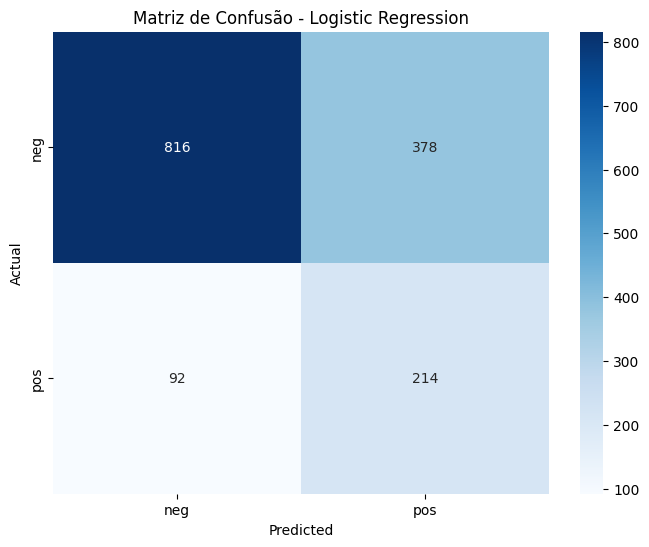

In [48]:
model_name = "Logistic Regression"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")

cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: Random Forest
              precision    recall  f1-score   support

           0     0.9254    0.7789    0.8458      1194
           1     0.4667    0.7549    0.5768       306

    accuracy                         0.7740      1500
   macro avg     0.6960    0.7669    0.7113      1500
weighted avg     0.8318    0.7740    0.7910      1500



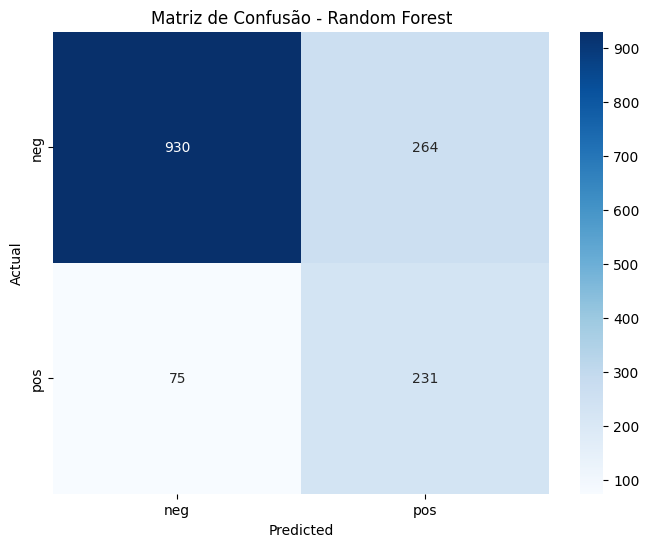

In [49]:
model_name = "Random Forest"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: Gradient Boosting
              precision    recall  f1-score   support

           0     0.9302    0.7814    0.8493      1194
           1     0.4748    0.7712    0.5878       306

    accuracy                         0.7793      1500
   macro avg     0.7025    0.7763    0.7186      1500
weighted avg     0.8373    0.7793    0.7960      1500



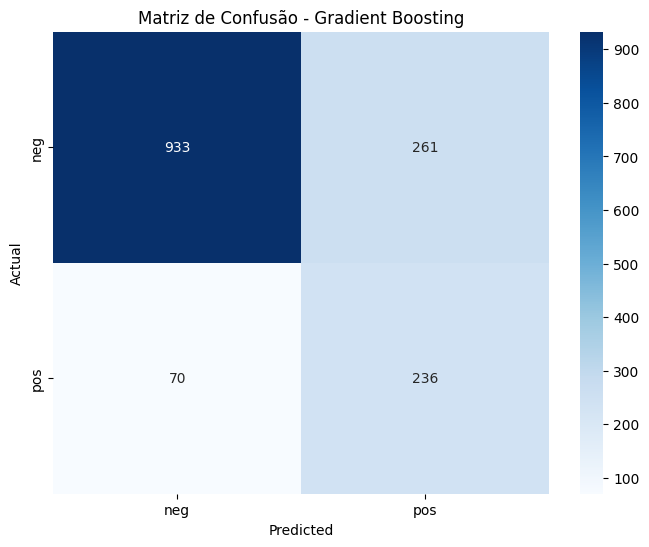

In [50]:
model_name = "Gradient Boosting"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: AdaBoost
              precision    recall  f1-score   support

           0     0.9156    0.7814    0.8432      1194
           1     0.4574    0.7190    0.5591       306

    accuracy                         0.7687      1500
   macro avg     0.6865    0.7502    0.7011      1500
weighted avg     0.8221    0.7687    0.7852      1500



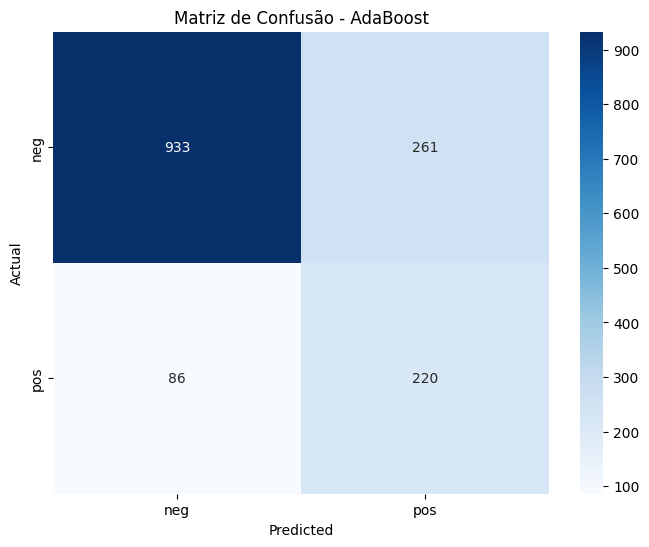

In [51]:
model_name = "AdaBoost"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: Bagging
              precision    recall  f1-score   support

           0     0.9159    0.7839    0.8448      1194
           1     0.4603    0.7190    0.5612       306

    accuracy                         0.7707      1500
   macro avg     0.6881    0.7514    0.7030      1500
weighted avg     0.8229    0.7707    0.7869      1500



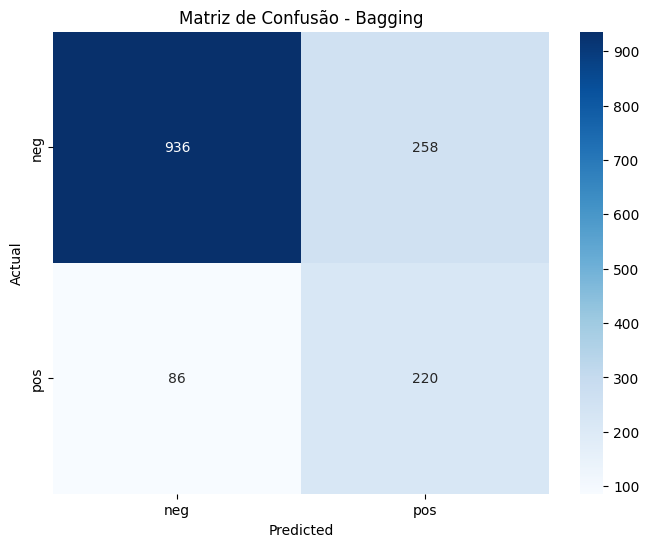

In [52]:
model_name = "Bagging"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: Extra Trees
              precision    recall  f1-score   support

           0     0.9196    0.7755    0.8414      1194
           1     0.4564    0.7353    0.5632       306

    accuracy                         0.7673      1500
   macro avg     0.6880    0.7554    0.7023      1500
weighted avg     0.8251    0.7673    0.7847      1500



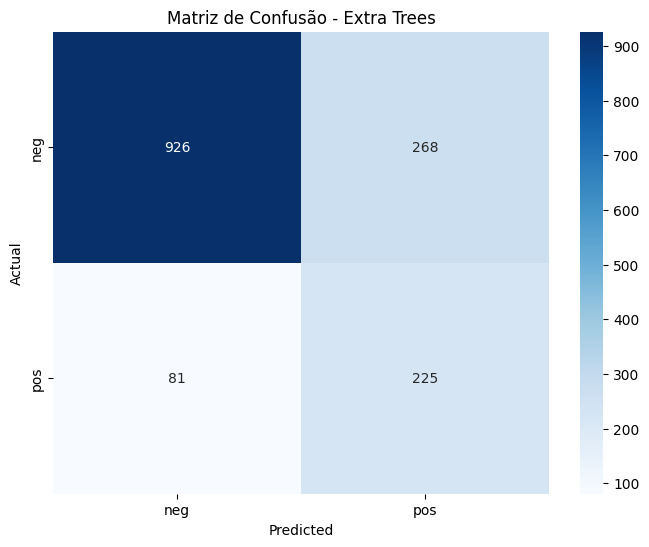

In [53]:
model_name = "Extra Trees"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: SVM
              precision    recall  f1-score   support

           0     0.8429    0.4045    0.5467      1194
           1     0.2330    0.7059    0.3504       306

    accuracy                         0.4660      1500
   macro avg     0.5380    0.5552    0.4485      1500
weighted avg     0.7185    0.4660    0.5066      1500



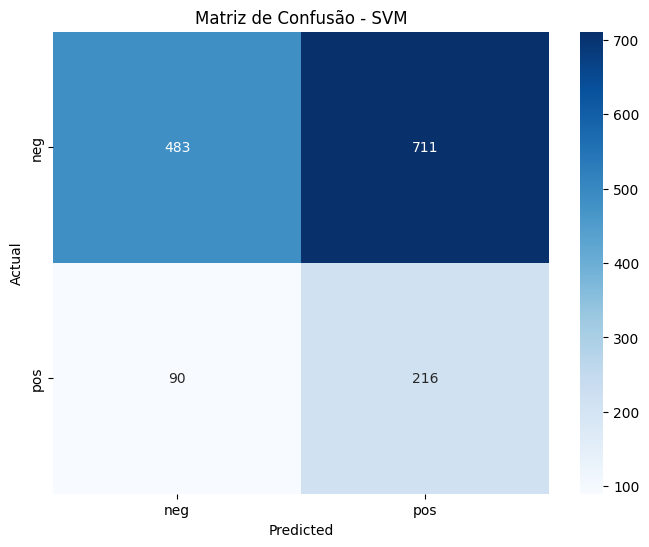

In [54]:
model_name = "SVM"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: KNN
              precision    recall  f1-score   support

           0     0.8029    0.5184    0.6300      1194
           1     0.2112    0.5033    0.2976       306

    accuracy                         0.5153      1500
   macro avg     0.5071    0.5108    0.4638      1500
weighted avg     0.6822    0.5153    0.5622      1500



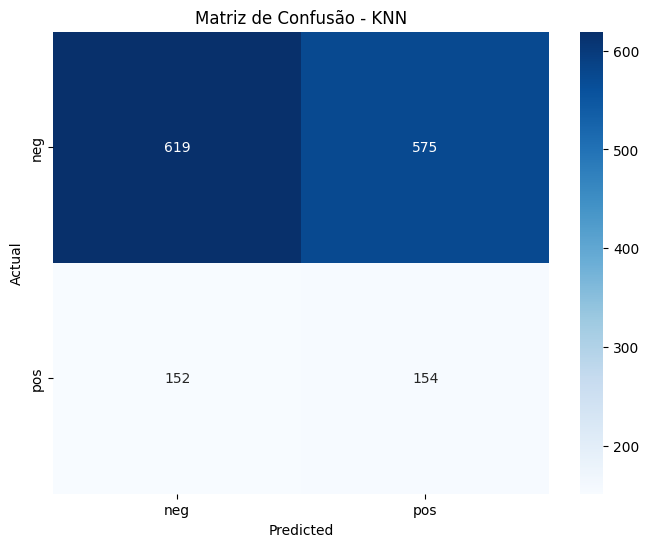

In [55]:
model_name = "KNN"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: XGBoost


              precision    recall  f1-score   support

           0     0.9183    0.7630    0.8335      1194
           1     0.4429    0.7353    0.5528       306

    accuracy                         0.7573      1500
   macro avg     0.6806    0.7491    0.6932      1500
weighted avg     0.8214    0.7573    0.7762      1500



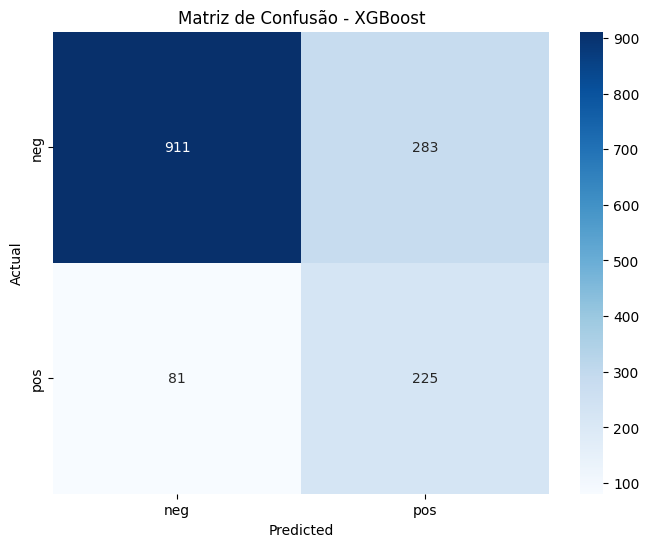

In [56]:
model_name = "XGBoost"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

Treinando: LightGBM
[LightGBM] [Info] Number of positive: 1426, number of negative: 1426
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000463 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 851
[LightGBM] [Info] Number of data points in the train set: 2852, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
              precision    recall  f1-score   support

           0     0.9224    0.7663    0.8371      1194
           1     0.4508    0.7484    0.5627       306

    accuracy                         0.7627      1500
   macro avg     0.6866    0.7573    0.6999      1500
weighted avg     0.8262    0.7627    0.7811      1500



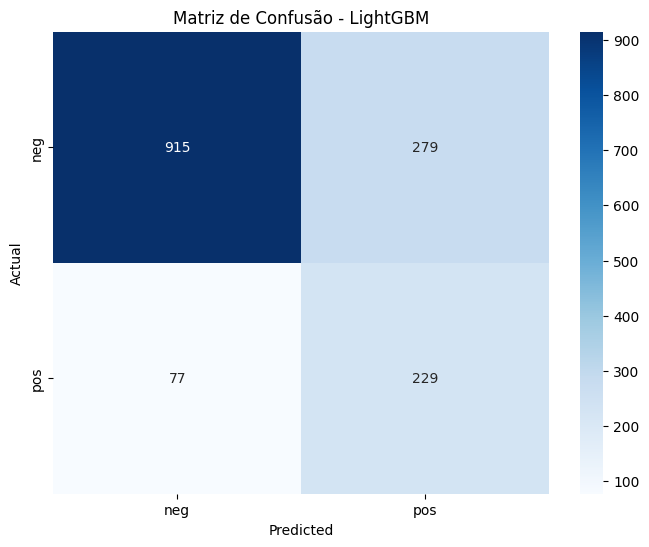

In [57]:
model_name = "LightGBM"
report, cm = executar_modelo(model_name, models[model_name], X_train_val, y_train_val, X_test, y_test)

print(report)
plot_confusion_matrix(cm, f"Matriz de Confusão - {model_name}")
cost_results[f"Baseline_{model_name}"] = calculate_model_cost(cm)

# Otimização de Hiperparâmetros

In [58]:
param_grids = {
    "Logistic Regression": {
        "model_instance": LogisticRegression(verbose=0),
        "params": lambda trial:{
            "C": trial.suggest_float("C", 1e-4, 1e2),
            "penalty": trial.suggest_categorical("penalty", ["l1", "l2"]),
            "solver": trial.suggest_categorical("solver", ["liblinear", "saga"]),
            "max_iter": trial.suggest_int("max_iter", 100, 2000),
        }
    },
    "Random Forest": {
        "model_instance": RandomForestClassifier(verbose=0),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 2, 32, log=True),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        }
    },
    "Gradient Boosting": {
        "model_instance": GradientBoostingClassifier(verbose=0),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1.0),
            "max_depth": trial.suggest_int("max_depth", 2, 16),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        }
    },
    "AdaBoost": {
        "model_instance": AdaBoostClassifier(),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1.0),
        }
    },
    "Bagging": {
        "model_instance": BaggingClassifier(verbose=0),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 10, 200),
            "max_samples": trial.suggest_float("max_samples", 0.5, 1.0),
            "max_features": trial.suggest_float("max_features", 0.5, 1.0),
            "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        }
    },
    "Extra Trees": {
        "model_instance": ExtraTreesClassifier(verbose=0),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 2, 32, log=True),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        }
    },
    "KNN": {
        "model_instance": KNeighborsClassifier(),
        "params": lambda trial:{
            "n_neighbors": trial.suggest_int("n_neighbors", 2, 30),
            "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
            "p": trial.suggest_int("p", 1, 2),
        }
    },
    "XGBoost": {
        "model_instance": XGBClassifier(verbosity=0, use_label_encoder=False),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 2, 16),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1.0),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "gamma": trial.suggest_float("gamma", 1e-8, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0),
        }
    },
    "LightGBM": {
        "model_instance": LGBMClassifier(),
        "params": lambda trial:{
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 2, 32),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1.0),
            "num_leaves": trial.suggest_int("num_leaves", 7, 256),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0),
        }
    },
    # "SVM": {
    #     "model_instance": SVC(verbose=0),
    #     "params": lambda trial:{
    #         "C": trial.suggest_float("C", 1e-4, 1e2),
    #         "kernel": trial.suggest_categorical("kernel", ["linear", "rbf", "sigmoid"]),
    #         "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
    #         "degree": trial.suggest_int("degree", 2, 5),
    #     }
    # },
}

In [59]:
def objective(trial, model_instance, param_grid, X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val):
    params = param_grid(trial)
    clf = model_instance.__class__(**params)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    
    return f1_score(y_val, y_pred, pos_label=1)

In [ ]:
tuning_results = dict()

optuna.logging.set_verbosity(optuna.logging.WARNING)
for model_name, clf_data in list(param_grids.items()):
    print(f'Otimizando: {model_name}')
    study = optuna.create_study(direction='maximize')
    
    study.optimize(lambda trial: objective(trial, clf_data['model_instance'], clf_data['params']), n_trials=300)
    best_params = study.best_params
    trials = study.trials_dataframe()
    tuning_results[model_name] = dict()
    tuning_results[model_name]['best_params'] = best_params


Otimizando: Logistic Regression
Otimizando: Random Forest


## Métricas dos Modelos Otimizados

In [ ]:
for key, value in tuning_results.items():
    print(key, value)
    results = tuning_results[key]
    best_params = results['best_params']
    
    model = param_grids[key]['model_instance'].__class__(**best_params)

    model.fit(X_train, y_train)
    prediction = model.predict(X_test)

    # print(classification_report(y_test, prediction))

    cm = confusion_matrix(y_test, prediction)
    # plot_confusion_matrix(cm, 'Matriz de Confusão')

    cost_matrix = [[0, 230], [791.40, 0]]
    cost_result = np.sum(cm * cost_matrix)
    cost_results[f"Optmized_{key}"] = cost_result

Logistic Regression {'best_params': {'C': 12.587647373025366, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 325}}
Random Forest {'best_params': {'n_estimators': 246, 'max_depth': 26, 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': False}}
Gradient Boosting {'best_params': {'n_estimators': 262, 'learning_rate': 0.9076894009750107, 'max_depth': 9, 'subsample': 0.5160803085247034, 'min_samples_split': 4, 'min_samples_leaf': 17}}
AdaBoost {'best_params': {'n_estimators': 196, 'learning_rate': 0.9751270316367058}}
Bagging {'best_params': {'n_estimators': 61, 'max_samples': 0.9998878485842925, 'max_features': 0.9821125184375665, 'bootstrap': False}}
Extra Trees {'best_params': {'n_estimators': 299, 'max_depth': 32, 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': False}}
KNN {'best_params': {'n_neighbors': 2, 'weights': 'distance', 'p': 2}}
XGBoost {'best_params': {'n_estimators': 247, 'max_depth': 4, 'learning_rate': 0.7736533024284736, 'subsample': 0.5457157989

In [ ]:
cost_results_df = pd.DataFrame(list(cost_results.items()), columns=['Modelo', 'Custo dos Erros'])
cost_results_df = cost_results_df.sort_values(by='Custo dos Erros', ascending=True)
cost_results_df.reset_index(drop=True, inplace=True)
cost_results_df['Custo dos Erros'] = cost_results_df['Custo dos Erros'].apply(lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
cost_results_df


,Modelo,Custo dos Erros
0,Baseline_Gradient Boosting,"R$ 115.428,00"
1,Baseline_Random Forest,"R$ 120.075,00"
2,Baseline_LightGBM,"R$ 125.107,80"
3,Baseline_Extra Trees,"R$ 125.743,40"
4,Baseline_Bagging,"R$ 127.400,40"
5,Baseline_AdaBoost,"R$ 128.090,40"
6,Baseline_XGBoost,"R$ 129.193,40"
7,Optmized_LightGBM,"R$ 135.601,40"
8,Optmized_Random Forest,"R$ 143.258,20"
9,Optmized_AdaBoost,"R$ 145.382,60"
